In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df= pd.read_csv("/content/stressdata.csv")
df2=pd.read_csv("/content/stressdata_preprocessed.csv")

<Axes: xlabel='Stress Level', ylabel='Count'>

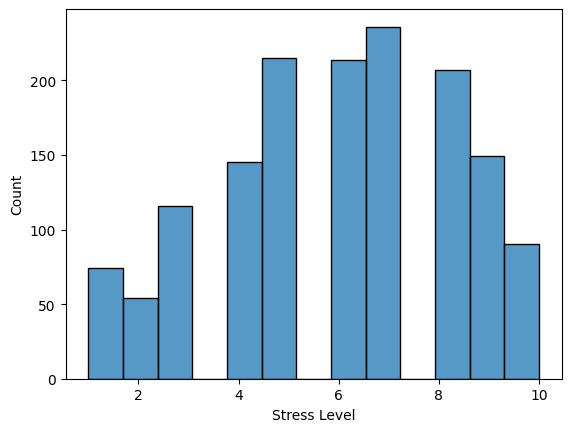

In [33]:
sns.histplot(df['Stress Level'])

<Axes: xlabel='Age', ylabel='Count'>

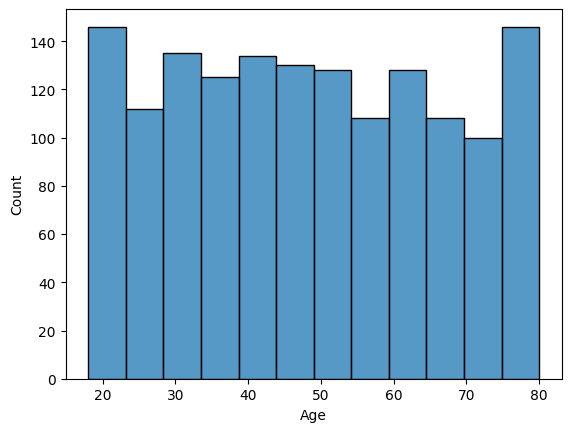

In [34]:
sns.histplot(df['Age'])

<Axes: xlabel='count', ylabel='Gender'>

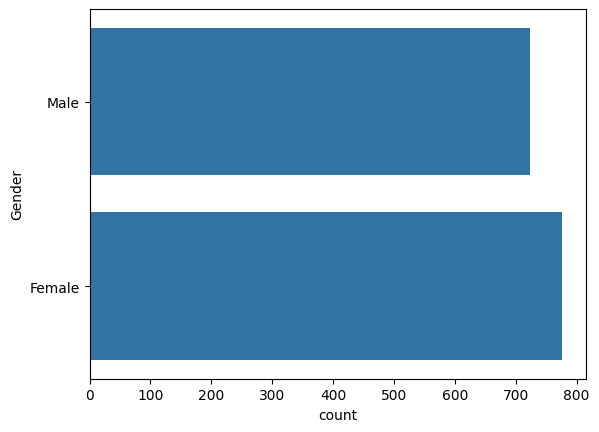

In [35]:
sns.countplot(df['Gender'])

<Axes: xlabel='Sleep Duration', ylabel='Stress Level'>

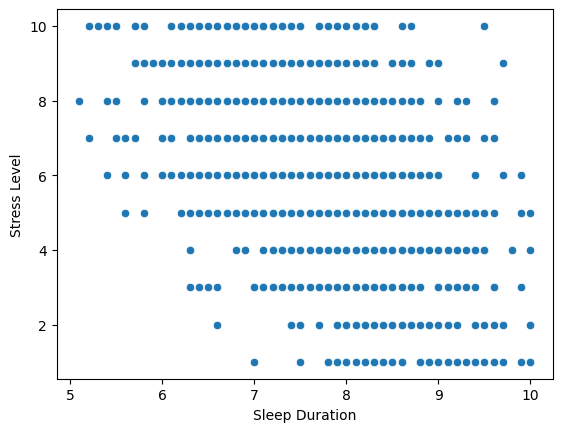

In [36]:
sns.scatterplot(x='Sleep Duration', y='Stress Level', data=df)

## Exploratory Data Analysis (EDA) - Initial Overview

This section begins our Exploratory Data Analysis (EDA) on the original dataset, `df`, loaded from `stressdata.csv`. The primary goal here is to gain a foundational understanding of the dataset's structure, data types, and basic statistical properties. This initial exploration is crucial for identifying potential data quality issues, understanding feature characteristics, and informing subsequent preprocessing steps.

### Logic & Requirements

We utilize `df.info()` to inspect the DataFrame's structure, including column names, non-null counts, and data types. Following this, `df.describe()` provides key statistical summaries for numerical columns (count, mean, standard deviation, min/max, quartiles).

**Requirements:** The `df` DataFrame must be loaded and available in the environment.

### Initial Conclusions & Interlinked Summary

*   `df.info()` reveals 13 columns with various data types (int64, float64, object). It highlights the presence of missing values in the 'Sleep Disorder' column, as indicated by a `Non-Null Count` of 539 out of 1500 entries. All other columns appear to be complete.
*   `df.describe()` offers quick insights into the distribution and range of numerical features such as 'Age', 'Sleep Duration', 'Stress Level', 'Heart Rate', etc. For instance, 'Stress Level' ranges from 3 to 8, and 'Age' from 24 to 60.

This initial overview confirms the need to address missing values, especially in 'Sleep Disorder', before any model training. The statistics provide a baseline for understanding the scale and spread of our numerical features, which will be critical when comparing to the preprocessed `df2` later.

In [37]:
print("DataFrame Info:")
df.info()

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                1500 non-null   int64  
 1   Gender                   1500 non-null   object 
 2   Age                      1500 non-null   int64  
 3   Occupation               1500 non-null   object 
 4   Sleep Duration           1500 non-null   float64
 5   Quality of Sleep         1500 non-null   int64  
 6   Physical Activity Level  1500 non-null   int64  
 7   Stress Level             1500 non-null   int64  
 8   BMI Category             1500 non-null   object 
 9   Blood Pressure           1500 non-null   object 
 10  Heart Rate               1500 non-null   int64  
 11  Daily Steps              1500 non-null   int64  
 12  Sleep Disorder           539 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 152.5+ KB


In [38]:
print("Descriptive Statistics for Numerical Columns:")
display(df.describe())

Descriptive Statistics for Numerical Columns:


,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,750.500000,48.394667,7.751733,5.825333,59.190000,6.012000,74.763333,6119.56600
std,433.157015,18.160510,0.900761,1.782772,38.266636,2.366909,12.237340,2823.00209
min,1.000000,18.000000,5.100000,1.000000,0.000000,1.000000,43.000000,1000.00000
25%,375.750000,33.000000,7.200000,5.000000,30.000000,4.000000,66.000000,3983.50000
50%,750.500000,47.000000,7.700000,6.000000,55.000000,6.000000,75.000000,5823.50000
75%,1125.250000,64.000000,8.400000,7.000000,83.250000,8.000000,83.000000,8028.00000
max,1500.000000,80.000000,10.000000,10.000000,180.000000,10.000000,109.000000,16036.00000


### Checking for Missing Values

It's crucial to identify and handle missing data. Let's see how many missing values each column has.

In [39]:
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


### Visualizing Distributions of Numerical Features

We've already plotted 'Age' and 'Stress Level' histograms, and a scatter plot for 'Sleep Duration' vs 'Stress Level'. Let's look at the distributions of other numerical features.

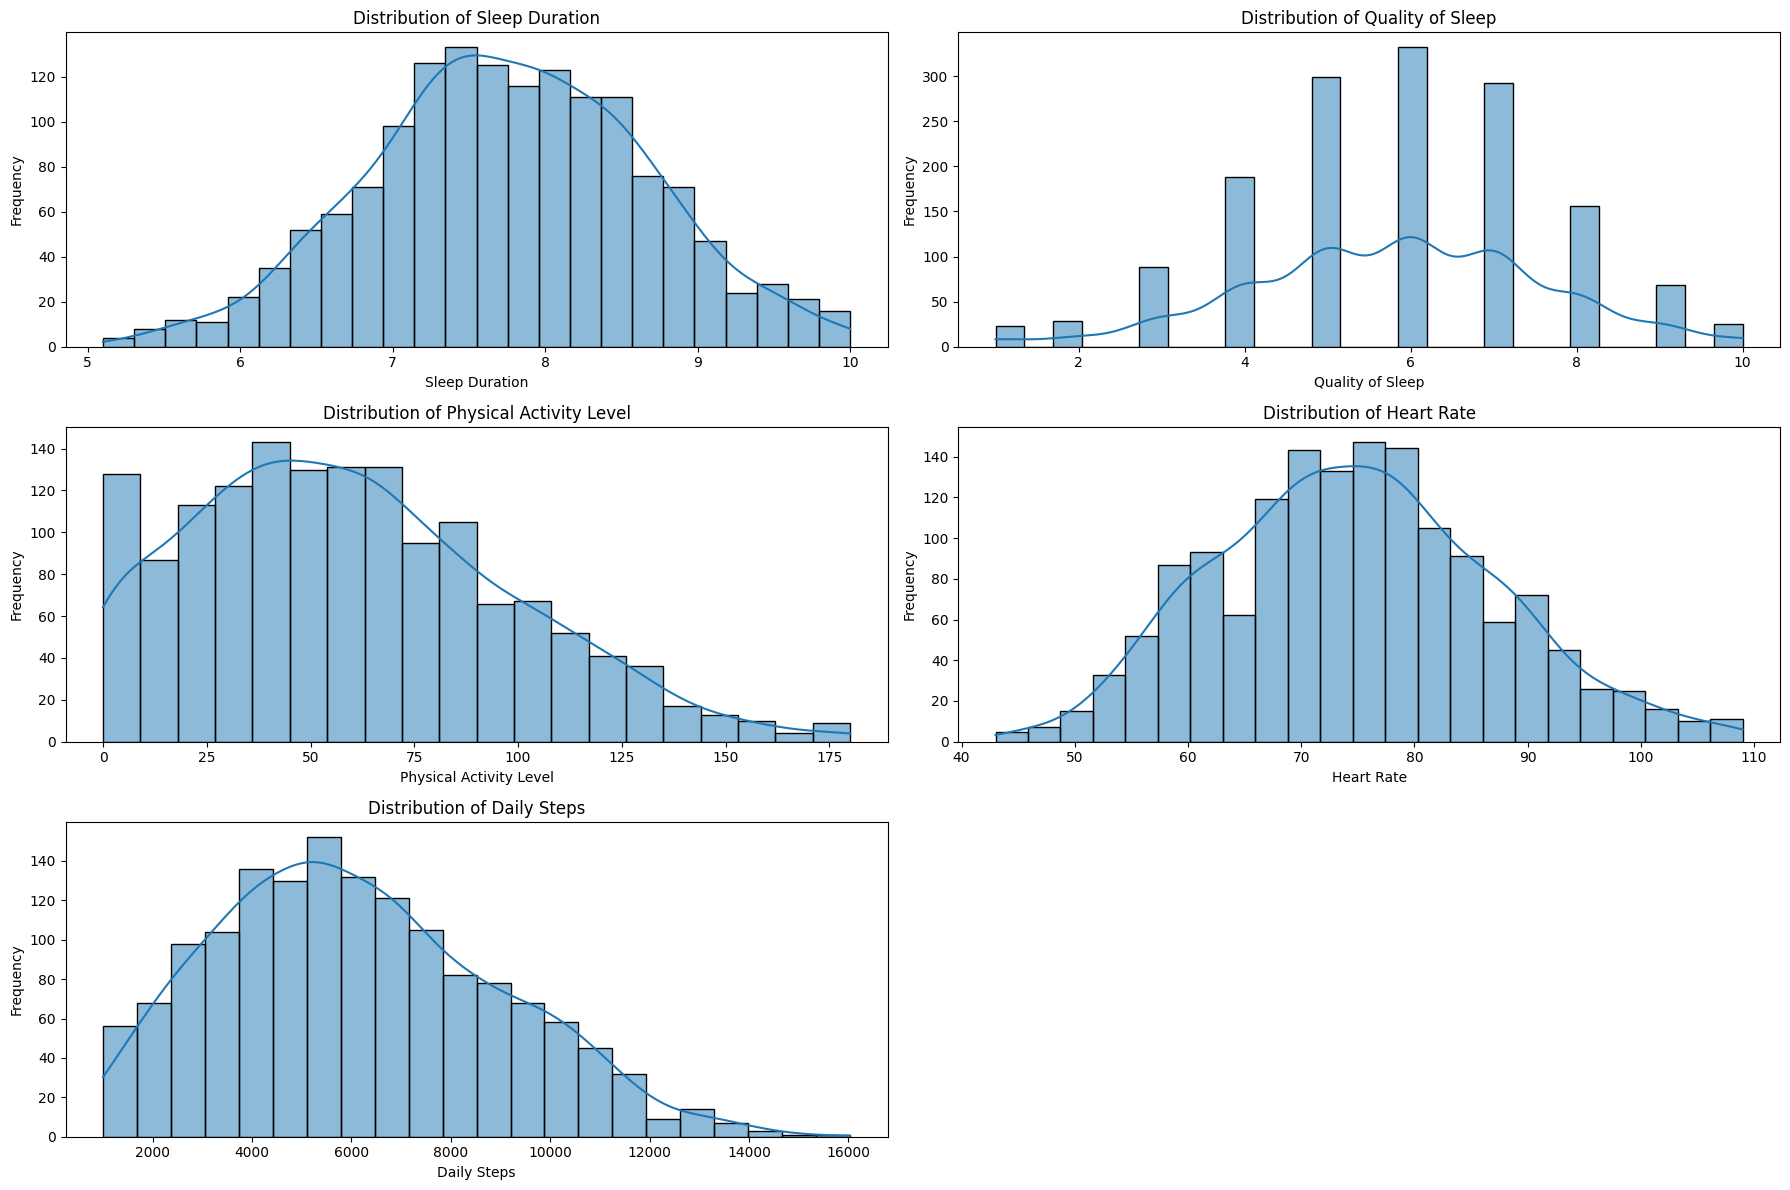

In [40]:
numerical_cols = ['Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Heart Rate', 'Daily Steps']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Visualizing Distributions of Categorical Features

We've already plotted the count of 'Gender'. Let's visualize the counts of 'Occupation', 'BMI Category', and 'Sleep Disorder'.

/tmp/ipykernel_626/1240952907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_626/1240952907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_626/1240952907.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')


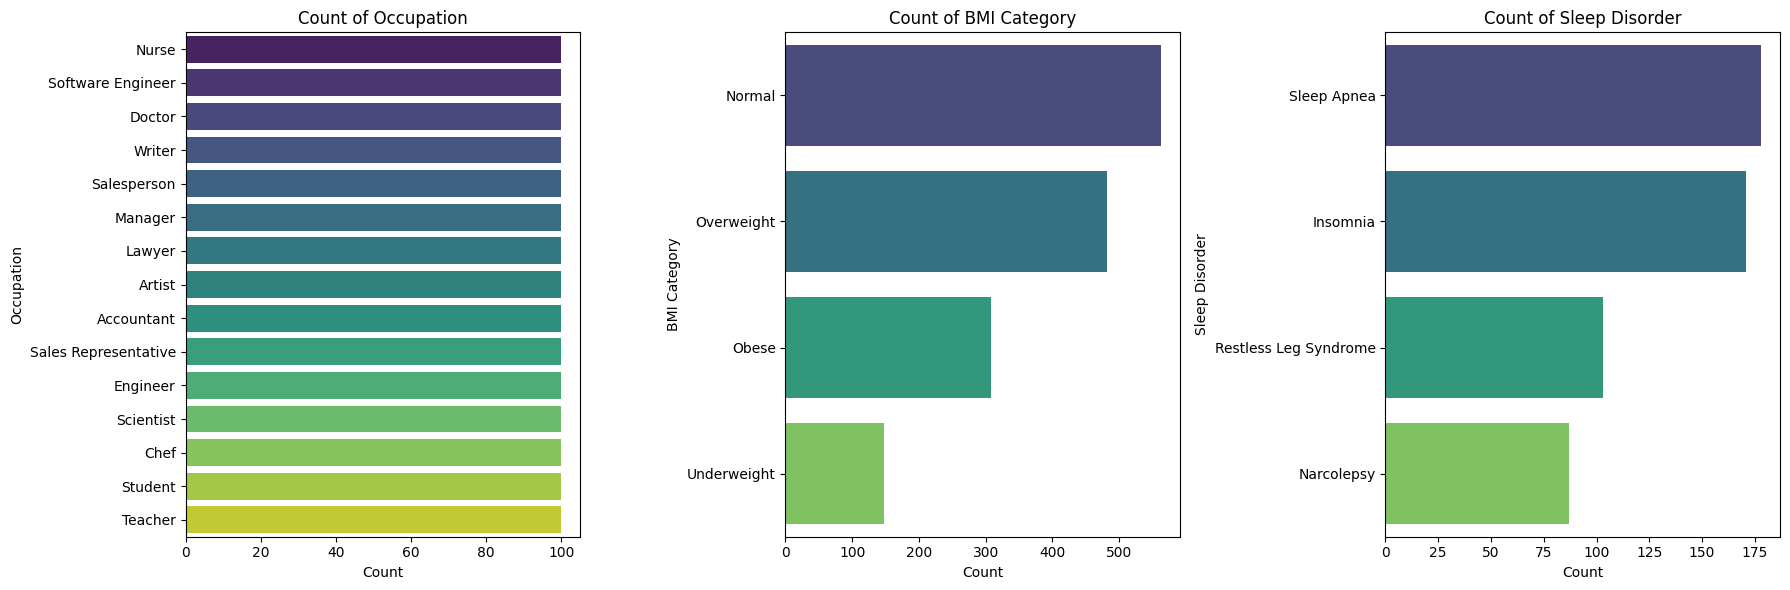

In [41]:
categorical_cols = ['Occupation', 'BMI Category', 'Sleep Disorder']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features

Let's examine the correlation between numerical features to understand their linear relationships.

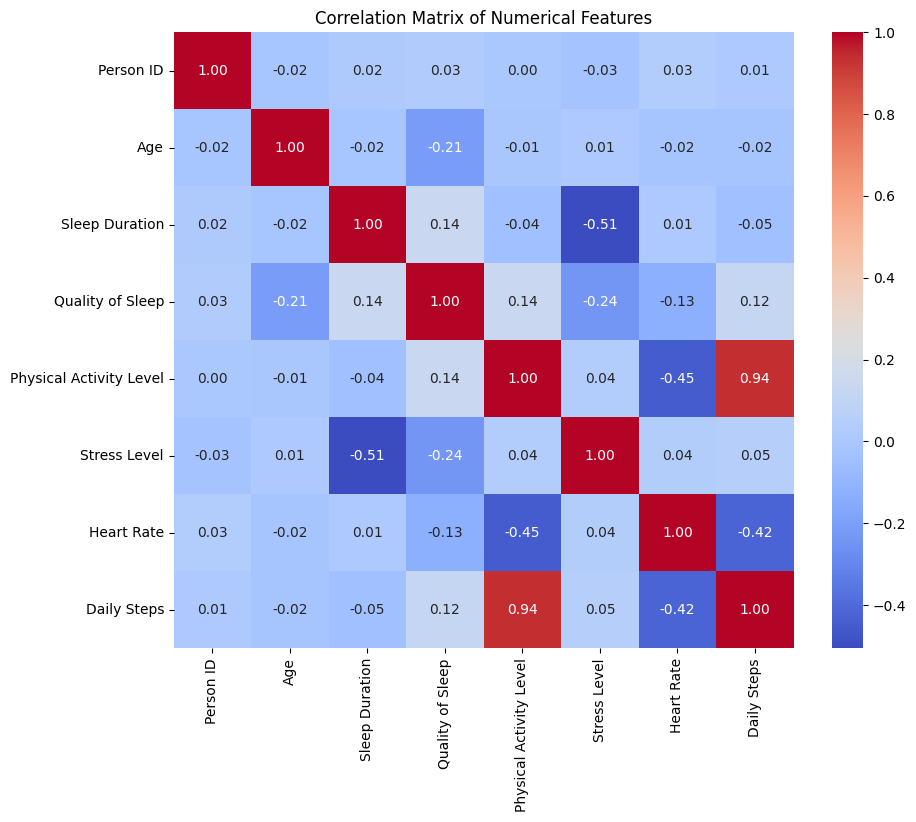

In [42]:
# Extract numerical columns for correlation matrix
numerical_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Exploratory Data Analysis (EDA) on Preprocessed Data (`df2`)

Let's get a general overview of the preprocessed dataset, including its structure, data types, and basic statistics.

In [43]:
print("DataFrame Info for df2:")
df2.info()

DataFrame Info for df2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Gender                           1500 non-null   float64
 1   Age                              1500 non-null   float64
 2   Sleep Duration                   1500 non-null   float64
 3   Quality of Sleep                 1500 non-null   float64
 4   Physical Activity Level          1500 non-null   float64
 5   BMI Category                     1500 non-null   float64
 6   Heart Rate                       1500 non-null   float64
 7   Daily Steps                      1500 non-null   float64
 8   Sleep Disorder                   1500 non-null   float64
 9   Systolic_BP                      1500 non-null   float64
 10  Diastolic_BP                     1500 non-null   float64
 11  Occupation_Artist                1500 non-null   float64
 

In [44]:
print("Descriptive Statistics for Numerical Columns in df2:")
display(df2.describe())

Descriptive Statistics for Numerical Columns in df2:


,Gender,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic_BP,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Student,Occupation_Teacher,Occupation_Writer,Stress Level
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,...,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,0.482667,0.490237,0.511362,0.480083,0.362288,0.544667,0.484906,0.390789,0.359333,0.455660,...,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,0.066667,6.012000
std,0.499866,0.292911,0.195500,0.218135,0.232938,0.305372,0.186745,0.215046,0.479965,0.208976,...,0.249527,0.249527,0.249527,0.249527,0.249527,0.249527,0.249527,0.249527,0.249527,2.366909
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.241935,0.391304,0.375000,0.183908,0.333333,0.351145,0.227839,0.000000,0.294118,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,0.000000,0.467742,0.500000,0.500000,0.337165,0.666667,0.488550,0.368354,0.000000,0.450980,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,1.000000,0.741935,0.652174,0.625000,0.510345,0.666667,0.610687,0.536704,1.000000,0.607843,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000


### Checking for Missing Values in `df2`

In [45]:
print("Missing values per column in df2:")
display(df2.isnull().sum())

Missing values per column in df2:


,0
Gender,0
Age,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
BMI Category,0
Heart Rate,0
Daily Steps,0
Sleep Disorder,0
Systolic_BP,0


### Visualizing Distributions of Numerical Features in `df2`

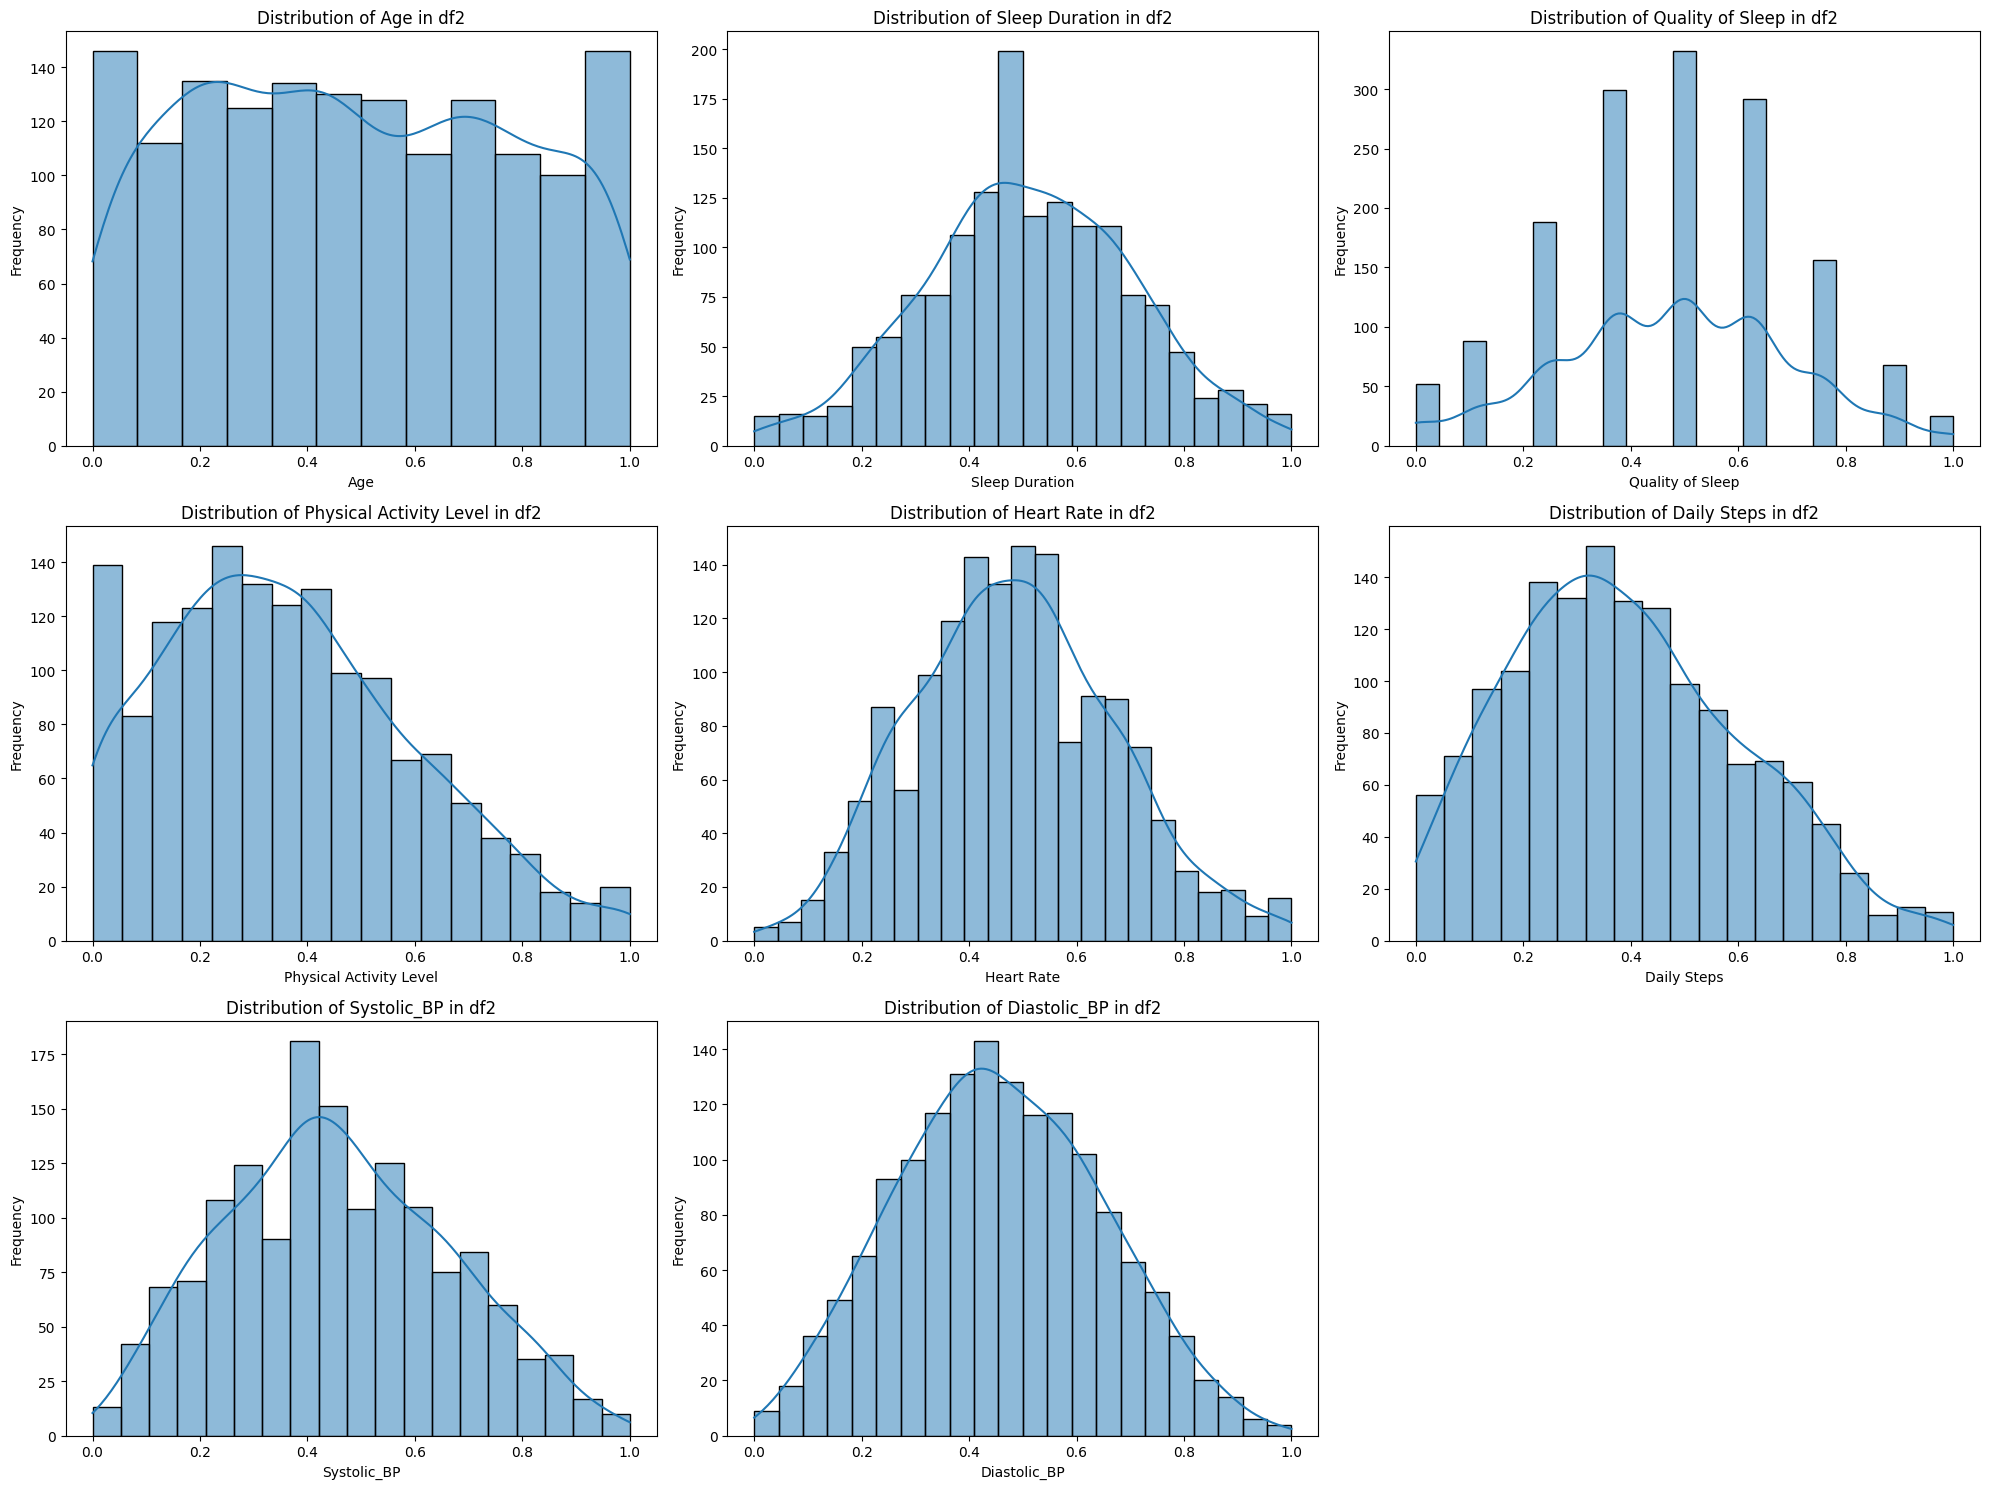

In [46]:
# Identify numerical columns from df2 that represent continuous or scaled quantities
# Exclude one-hot encoded columns for occupations, as their distributions are simple binary counts
numerical_cols_df2 = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP'
]

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_df2):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df2[col], kde=True)
    plt.title(f'Distribution of {col} in df2')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation Matrix of Numerical Features in `df2`

### Visualizing Distributions of Numerical Features in `df2`

### Bivariate Analysis: 'Stress Level' vs. Numerical Features in `df2`

Let's visualize the relationship between the target variable, 'Stress Level', and the scaled numerical features in `df2`. Scatter plots are useful for observing trends, correlations, and potential patterns.

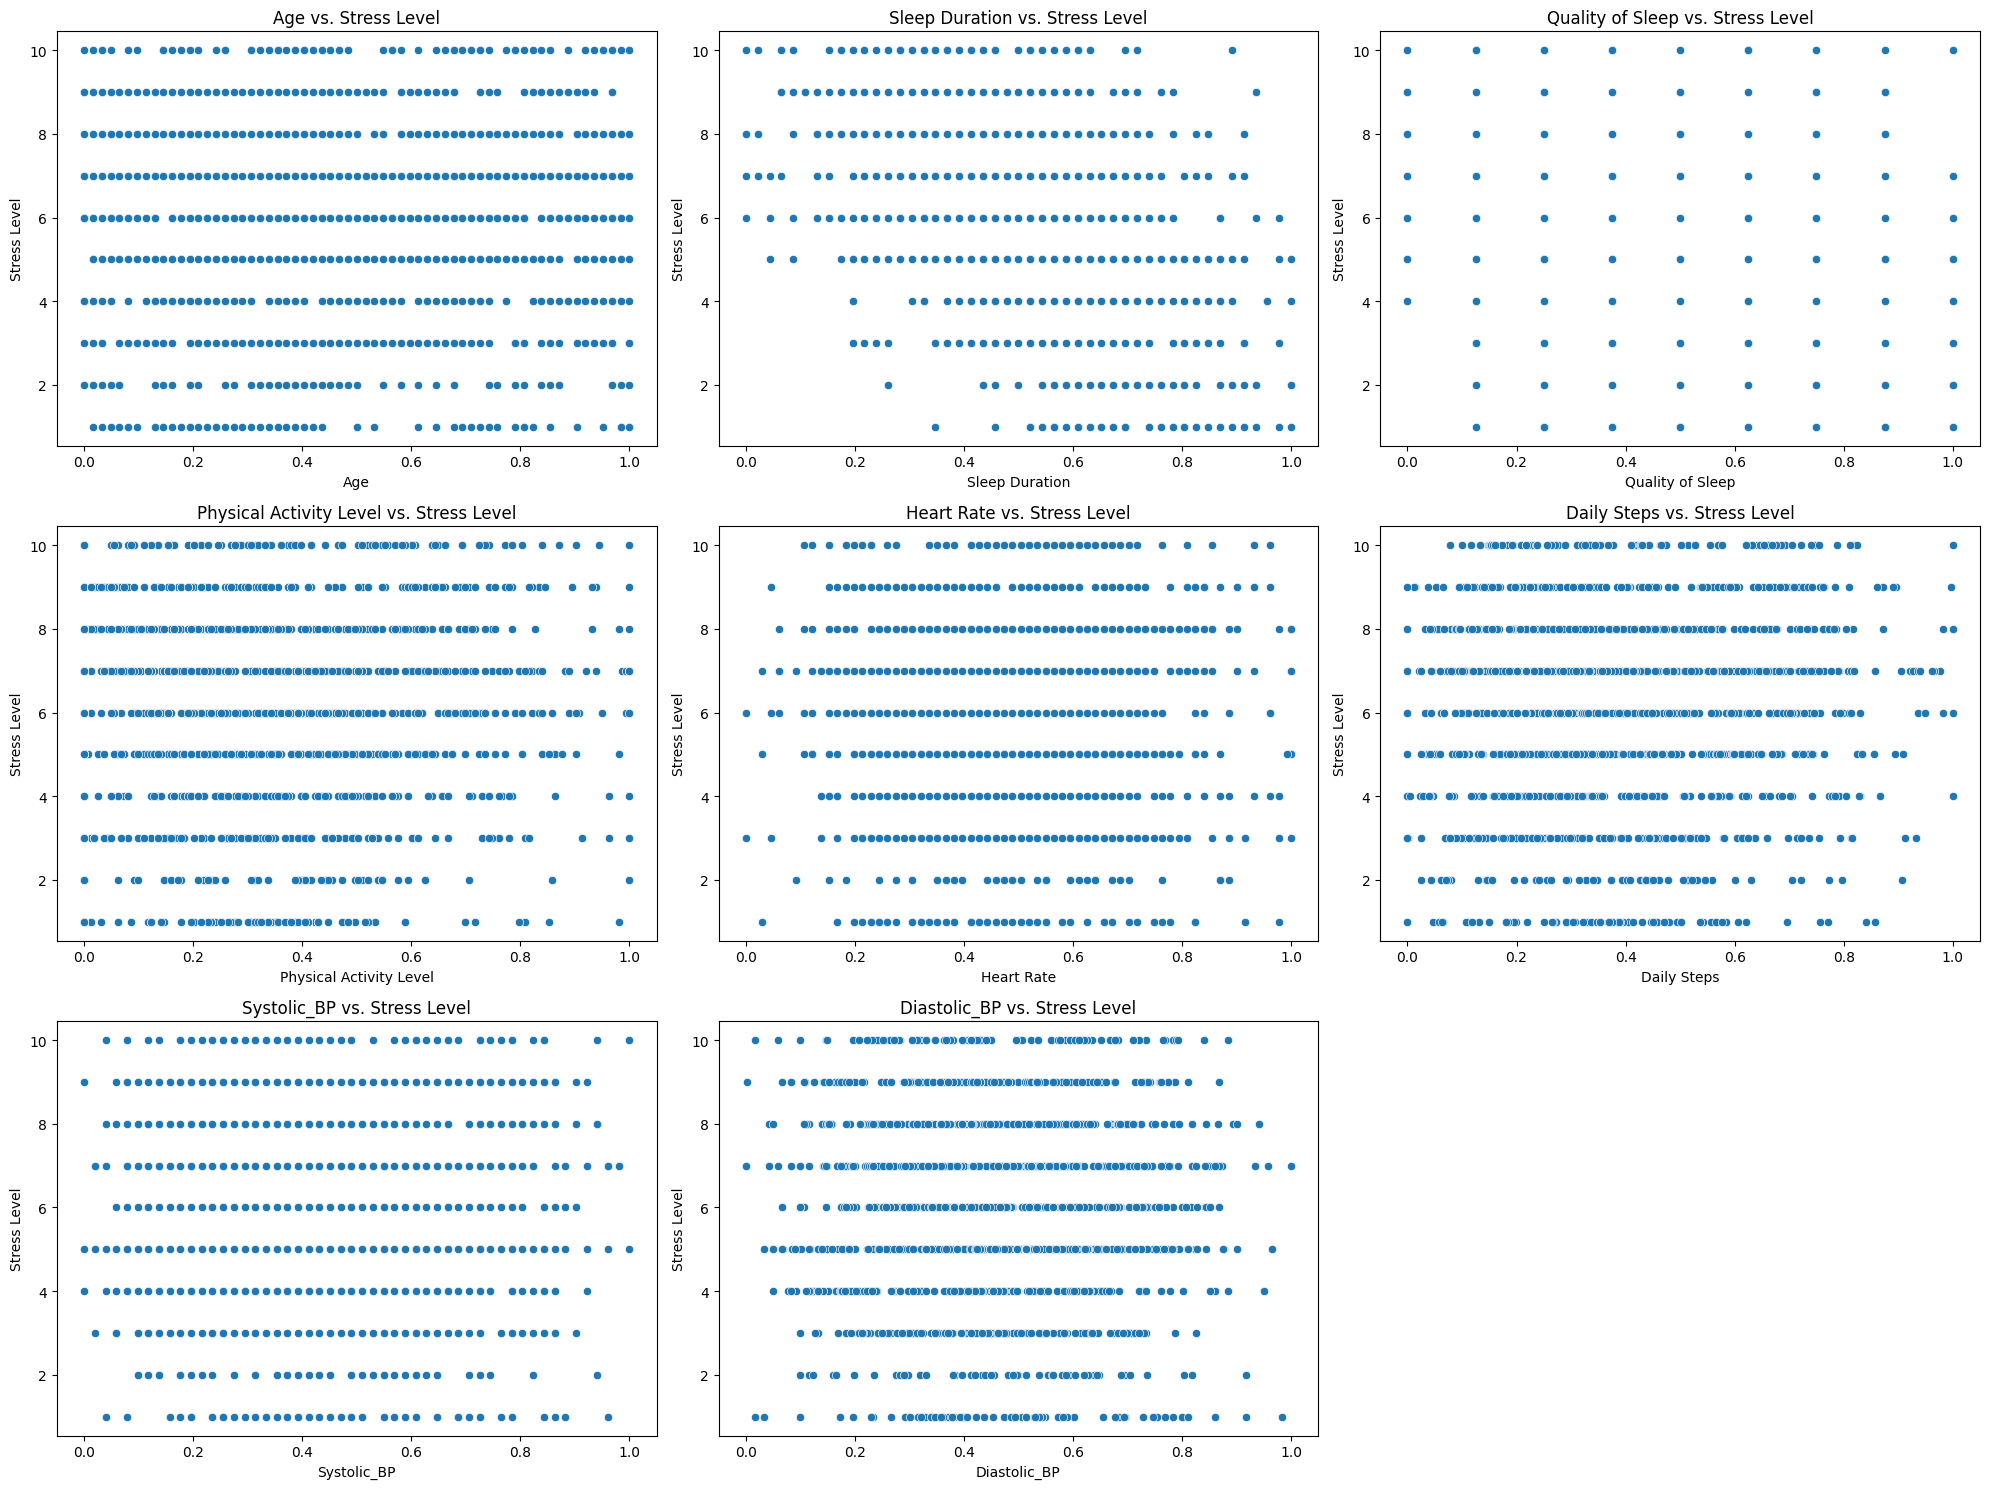

In [47]:
numerical_cols_for_bivariate = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP'
]

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_for_bivariate):
    plt.subplot(3, 3, i + 1)
    sns.scatterplot(x=df2[col], y=df2['Stress Level'])
    plt.title(f'{col} vs. Stress Level')
    plt.xlabel(col)
    plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

### Bivariate Analysis: 'Stress Level' vs. Encoded Categorical Features in `df2`

Now, let's examine 'Stress Level' against features that were originally categorical but are now encoded (like Gender, BMI Category, and Sleep Disorder). Box plots are suitable here to show the distribution of 'Stress Level' for each category.

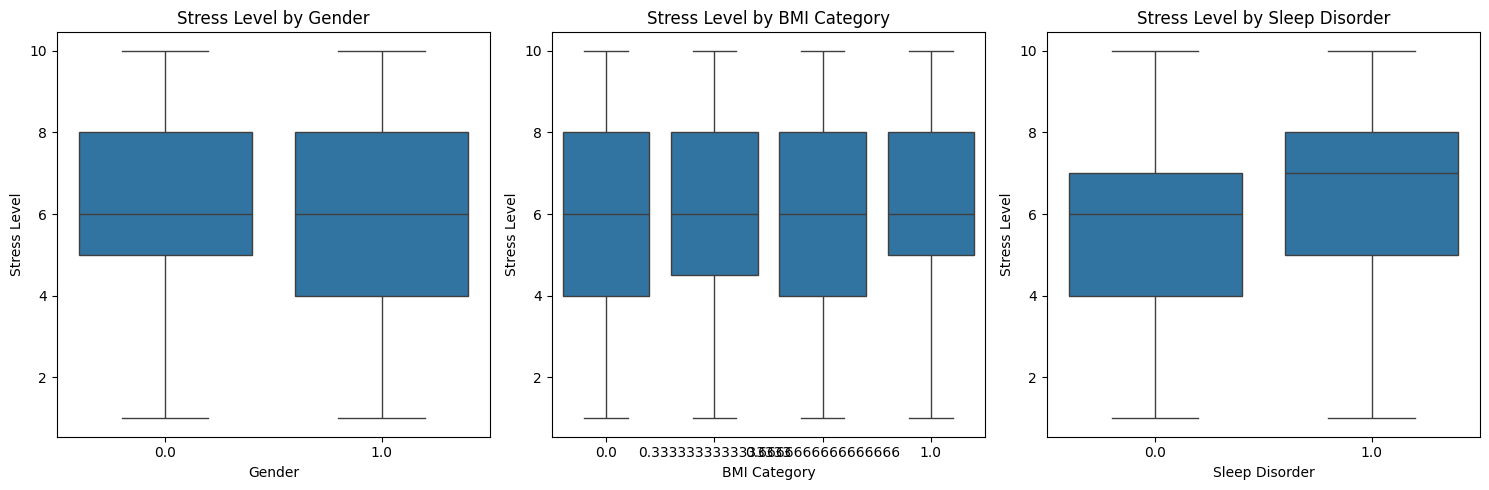

In [48]:
encoded_categorical_cols = ['Gender', 'BMI Category', 'Sleep Disorder']

plt.figure(figsize=(15, 5))
for i, col in enumerate(encoded_categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df2[col], y=df2['Stress Level'])
    plt.title(f'Stress Level by {col}')
    plt.xlabel(col)
    plt.ylabel('Stress Level')
plt.tight_layout()
plt.show()

### Bivariate Analysis: 'Stress Level' vs. 'Sleep Disorder' (Original Data `df`)

Let's visualize the relationship between 'Stress Level' and the specific types of 'Sleep Disorder' from the original `df` DataFrame. This will show the average stress level associated with each disorder.

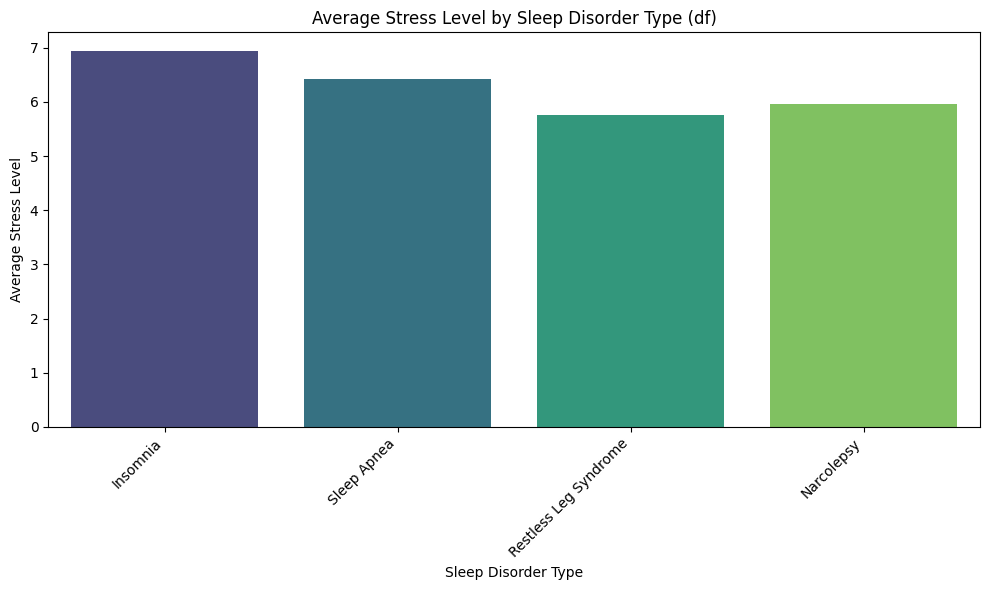

In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Sleep Disorder', y='Stress Level', data=df, palette='viridis', errorbar=None, hue='Sleep Disorder', legend=False)
plt.title('Average Stress Level by Sleep Disorder Type (df)')
plt.xlabel('Sleep Disorder Type')
plt.ylabel('Average Stress Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

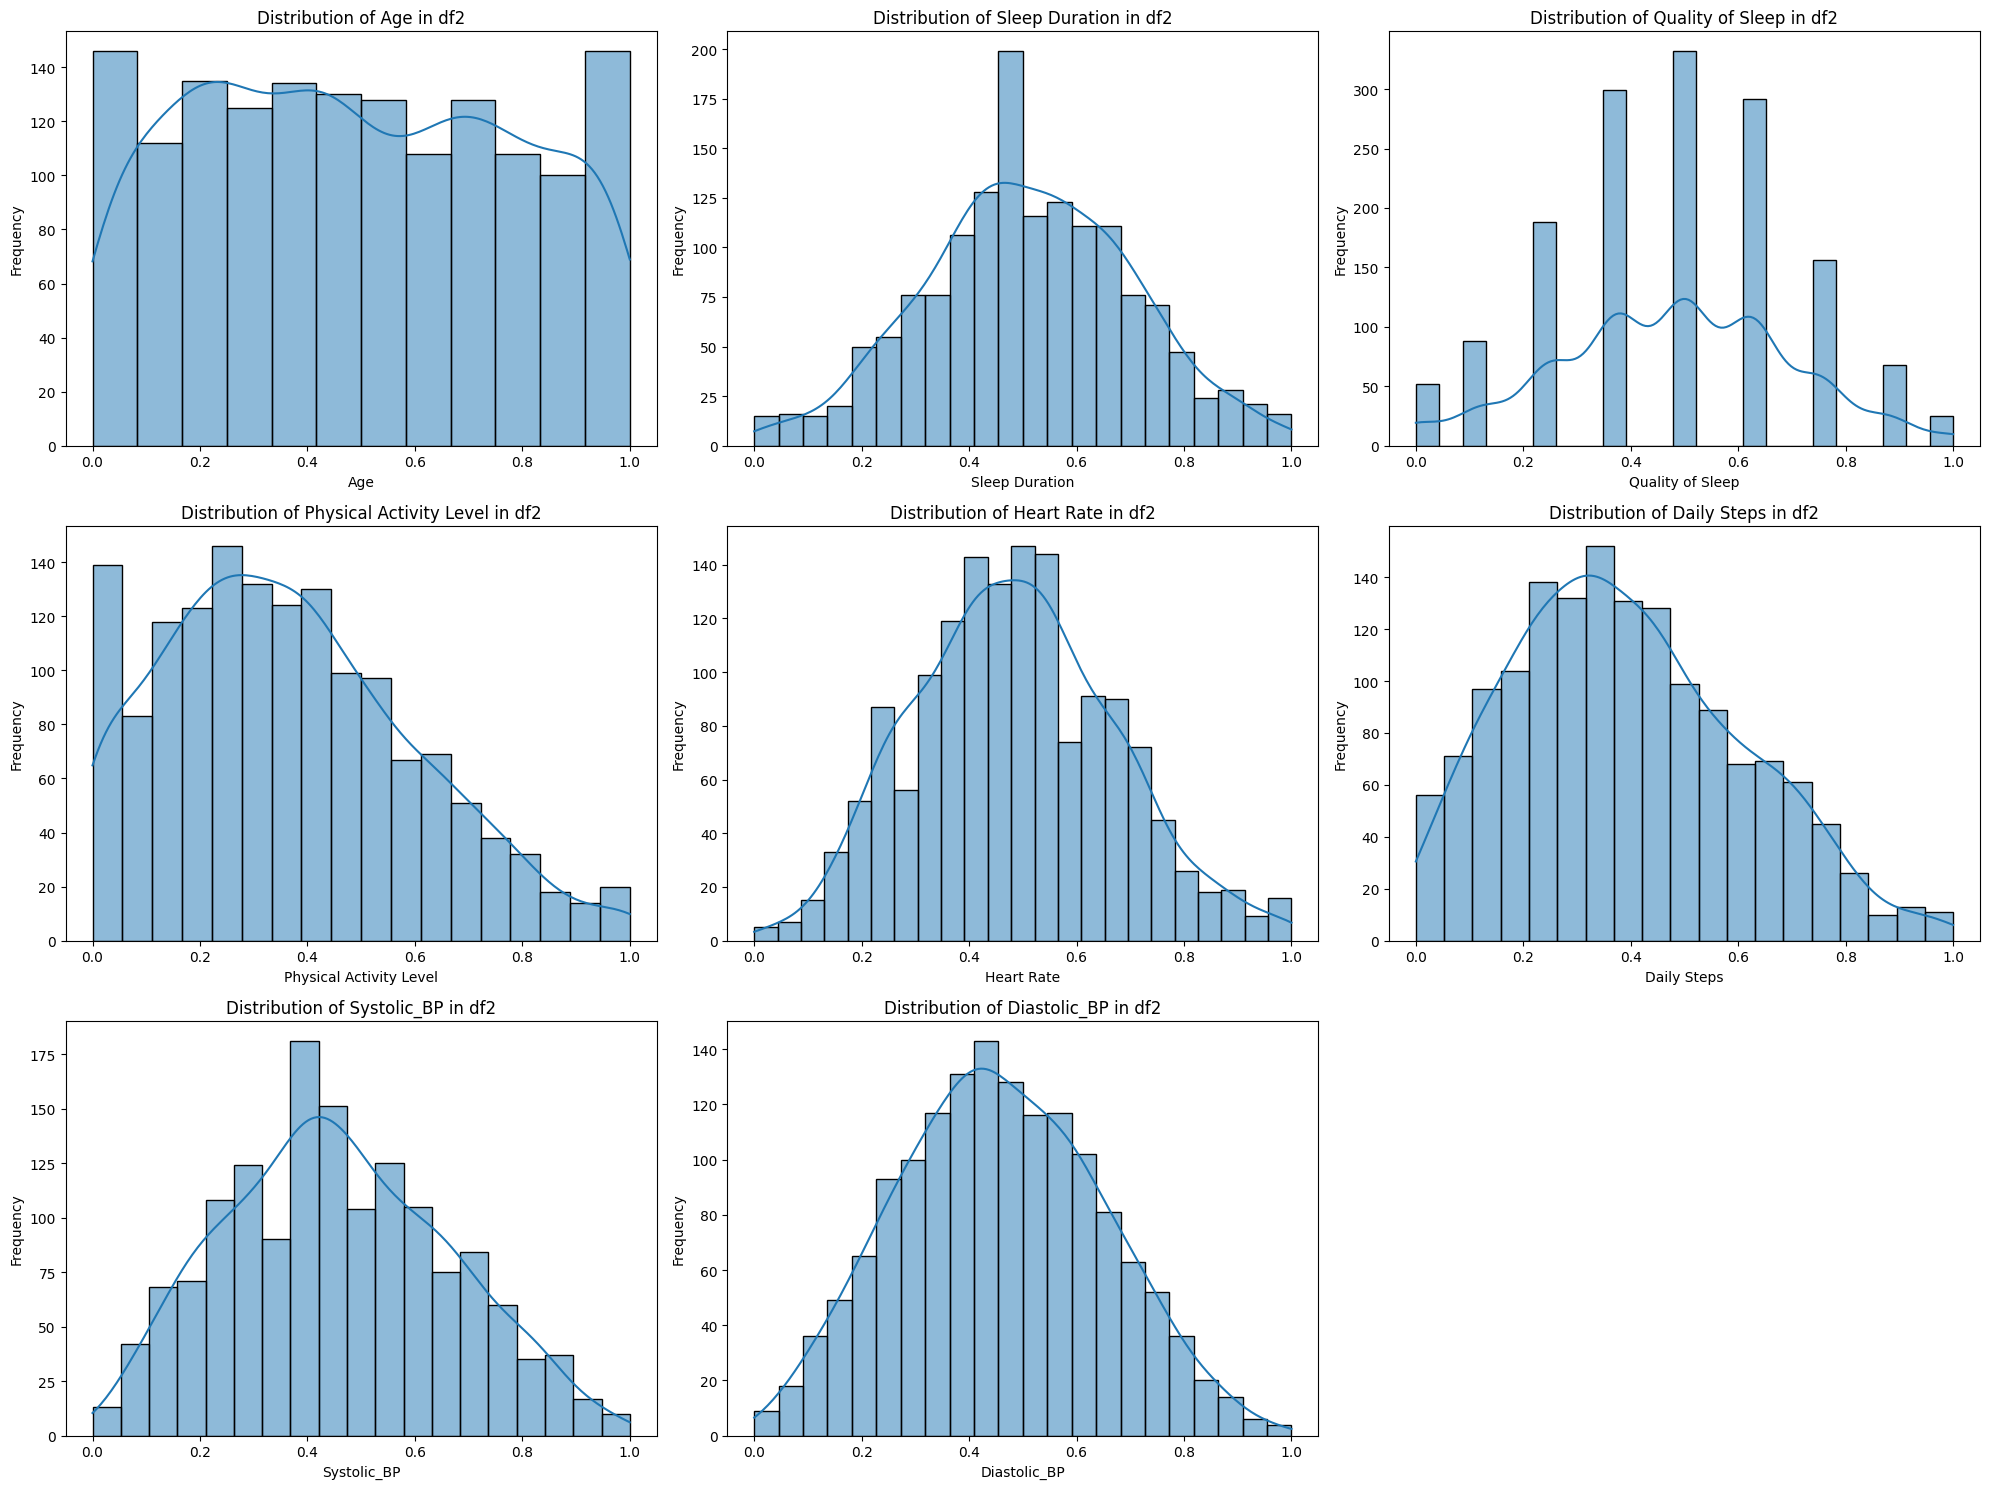

In [49]:
# Identify numerical columns from df2 that represent continuous or scaled quantities
# Exclude one-hot encoded columns for occupations, as their distributions are simple binary counts
numerical_cols_df2 = [
    'Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
    'Heart Rate', 'Daily Steps', 'Systolic_BP', 'Diastolic_BP'
]

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols_df2):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df2[col], kde=True)
    plt.title(f'Distribution of {col} in df2')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()